In [52]:
from modules import *
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



### Eurostat Turnover

In [53]:
to = pd.read_excel("Data/EU Manufacturing Turnover 2011-2020.xlsx", sheet_name='Sheet 1', header=8)

#clean column and names
NUMCOLS = [str(year) for year in range(2011, 2021)]
to.columns = ['country'] + [
    col for year in NUMCOLS for col in (year, f'{year}_flag')
]
to = to[[col for col in to.columns if '_flag' not in col] ]

#melt frame
to = to.melt('country', value_vars=NUMCOLS, value_name='turnover', var_name='year')

#again for present data from 2021 on
to1= pd.read_excel("Data/EU Net Turnover 2021-2024.xlsx", sheet_name='Sheet 1', header=9)
#clean column and names
NUMCOLS = [str(year) for year in range(2021, 2025)]
to1.columns = ['country'] + [
    col for year in NUMCOLS for col in (year, f'{year}_flag')
]
to1 = to1[[col for col in to1.columns if '_flag' not in col] ]

#melt frame
to1 = to1.melt('country', value_vars=NUMCOLS, value_name='turnover', var_name='year')

to = pd.concat([to,to1])

#keep spain
to = to[to['country'] == 'Spain']

to


/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,country,year,turnover
12,Spain,2011,469674.3
64,Spain,2012,457032
116,Spain,2013,447414.9
168,Spain,2014,455944.5
220,Spain,2015,467052.8
272,Spain,2016,466087.9
324,Spain,2017,505350.9
376,Spain,2018,551091.3
428,Spain,2019,560854.9
480,Spain,2020,497125.6


### Price Indexes Eurostat

In [54]:
#read data and set header names
file = "Data/Prices Eurostat 2015.xlsx"
ps = pd.read_excel(file, sheet_name='Sheet 1', header=10)

#clean colnames
NUMCOLS = [str(year) for year in range(2016, 2026)]
ps.columns = ['country', 'sector', 'sectorname'] + [
    col for year in NUMCOLS for col in (year, f'{year}_flag')
]

#drop flag columns
ps = ps[ [col for col in ps.columns if '_flag' not in col] ]

#set to numeric
for col in NUMCOLS:
    ps[col] = pd.to_numeric(ps[col], errors='coerce')

#only keep disaggregated sectorcodes for 2 digit sector
ps = ps[ps['sector'].str.fullmatch(r'[A-Z]\d+', na=False)]
ps = ps[ps['sector'].str.strip().str.len() == 3]
ps['sector2d'] = ps['sector'].str[1:]


#only keep spain 
ps = ps[ps['country'] == 'Spain']


#convert to long format
ps = ps.melt('sector2d', value_vars=NUMCOLS, value_name='priceind', var_name='year')

#divide index by 100 to get decimal
ps['priceind'] = ps['priceind'] / 100

ps

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,sector2d,year,priceind
0,05,2016,NaN
1,06,2016,NaN
2,07,2016,NaN
3,08,2016,0.956
4,09,2016,NaN
...,...,...,...
305,31,2025,1.139
306,32,2025,1.127
307,33,2025,1.108
308,35,2025,1.327


In [55]:
#capital prices eurostat
file = "Data/Capital Prices Eurostat 2015.xlsx"
capi = pd.read_excel(file, sheet_name='Sheet 1', header=10)

NUMCOLS = [str(year) for year in range(2016, 2026)]
capi.columns = ['country'] + [
    col for year in NUMCOLS for col in (year, f'{year}_flag')
][:-1]

#drop flag columns
capi = capi[ [col for col in capi.columns if '_flag' not in col] ]

#set to numeric
for col in NUMCOLS:
    capi[col] = pd.to_numeric(capi[col], errors='coerce')
capi['2015'] = 100

capi = capi.melt('country', value_vars=['2015']+NUMCOLS, value_name='capitalprice', var_name='year')
capi['capitalprice'] = capi['capitalprice'] / 100

capi = capi[capi['country'] == 'Spain']

capi


/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,country,year,capitalprice
14,Spain,2015,1.000
63,Spain,2016,1.006
112,Spain,2017,1.015
161,Spain,2018,1.024
210,Spain,2019,1.034
259,Spain,2020,1.043
308,Spain,2021,1.064
357,Spain,2022,1.121
406,Spain,2023,1.158
455,Spain,2024,NaN


### Real Interest Rate
To calculate real Interest rate we use [nominal interest rate](https://ec.europa.eu/eurostat/databrowser/view/irt_lt_mcby_a__custom_21686442/default/table) and [inflation rates](https://ec.europa.eu/eurostat/databrowser/view/prc_hicp_ainr__custom_21686600/default/table) from Eurostat.

$$ r_t^{\text{real}} = \frac{1 + r_t^{\text{nominal}}}{1 + \pi_t} - 1 $$

$$ r_t^{\text{real}} \approx r_t^{\text{nominal}} - \pi_t $$

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


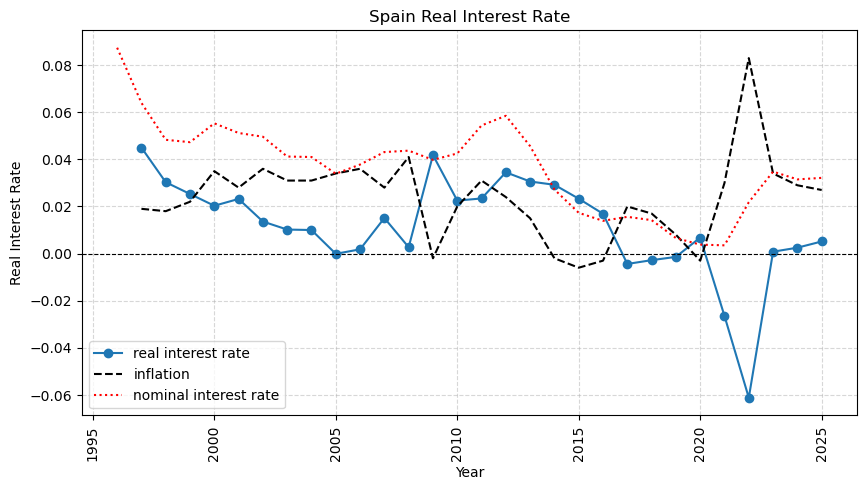

In [56]:
#capital prices eurostat
file = "Data/Nominal Interest Rate Eurostats.xlsx"
noi = pd.read_excel(file, sheet_name='Sheet 1', header=10)

NUMCOLS = [str(year) for year in range(1949, 2026)]
noi.columns = ['country'] + [
    col for year in NUMCOLS for col in (year, f'{year}_flag')
][:-1]

#drop flag columns
noi = noi[ [col for col in noi.columns if '_flag' not in col] ]

#set to numeric
for col in NUMCOLS:
    noi[col] = pd.to_numeric(noi[col], errors='coerce')


noi = noi.melt('country', value_vars=NUMCOLS, value_name='nominalinterestrate', var_name='year')
noi['nominalinterestrate'] = noi['nominalinterestrate'] / 100

noi = noi[noi['country'] == 'Spain']

#inflation
file = "Data/Inflation Eurostats.xlsx"
inf = pd.read_excel(file, sheet_name='Sheet 1', header=10)

NUMCOLS = [str(year) for year in range(1996, 2026)]
inf.columns = ['country'] + [
    col for year in NUMCOLS for col in (year, f'{year}_flag')
][:-1]
#drop flag columns
inf = inf[ [col for col in inf.columns if '_flag' not in col] ]
#set to numeric
for col in NUMCOLS:
    inf[col] = pd.to_numeric(inf[col], errors='coerce')
inf = inf.melt('country', value_vars=NUMCOLS, value_name='inflation', var_name='year')
inf['inflation'] = inf['inflation'] / 100
inf = inf[inf['country'] == 'Spain']


rirate = noi.merge(inf, on=['country', 'year'], how='inner')
rirate['realinterestrate'] = rirate['nominalinterestrate'] - rirate['inflation']

rirate['year'] = rirate['year'].astype(int)



plt.figure(figsize=(10, 5))

plt.plot(rirate['year'], rirate['realinterestrate'], marker='o', linestyle='-', label = 'real interest rate')
plt.plot(rirate['year'], rirate['inflation'], linestyle='--', color='black', label='inflation')
plt.plot(rirate['year'], rirate['nominalinterestrate'], linestyle=':', color='red', label='nominal interest rate')


plt.xlabel("Year")
plt.ylabel("Real Interest Rate")
plt.title("Spain Real Interest Rate")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=90)
plt.legend()

plt.show()

### read orbis data

In [57]:
#get list of relevant files
directory = Path("Data/Export 270426")
files = list(map(str, directory.glob("*.xlsx")))

# Usage
df = pd.DataFrame()
for file in files:
    dffile = read_orbis_excel(
        file,
        sheet_name="Ergebnisse"
    )
    df = pd.concat([df, dffile])


#replace n.v. with na
df = df.replace('n.v.', np.nan)

DESC_COLS = ['Unternehmensname Latin alphabet',
       'NACE Rev. 2 Core Code (4 Ziffern)']

#take num cols and drop 2014 and betriebsertrag
NUM_COLS = [col for col in df.columns if (col not in DESC_COLS) and ('2014' not in col) and ('Betriebsertrag' not in col)]

df = df[DESC_COLS + NUM_COLS]
df.describe()

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,NACE Rev. 2 Core Code (4 Ziffern),Unnamed: 0,Letztes verf. Jahr,Mitarbeiterkosten tsd EUR 2024,Mitarbeiterkosten tsd EUR 2023,Mitarbeiterkosten tsd EUR 2022,Mitarbeiterkosten tsd EUR 2021,Mitarbeiterkosten tsd EUR 2020,Mitarbeiterkosten tsd EUR 2019,Mitarbeiterkosten tsd EUR 2018,...,Anzahl der Mitarbeiter 2024,Anzahl der Mitarbeiter 2023,Anzahl der Mitarbeiter 2022,Anzahl der Mitarbeiter 2021,Anzahl der Mitarbeiter 2020,Anzahl der Mitarbeiter 2019,Anzahl der Mitarbeiter 2018,Anzahl der Mitarbeiter 2017,Anzahl der Mitarbeiter 2016,Anzahl der Mitarbeiter 2015
count,51885.000000,51885.000000,51885.0,48171.000000,48259.000000,4.791000e+04,47826.000000,47747.000000,47838.000000,47800.000000,...,46706.00000,46730.000000,46450.000000,46316.000000,46173.000000,46451.000000,46278.000000,46109.000000,45663.00000,44934.000000
mean,2174.684205,6743.482182,2024.0,1476.021080,1376.657927,1.281481e+03,1203.616637,1148.600550,1166.566900,1105.213582,...,31.62249,30.851230,30.292465,29.257794,28.383687,28.730985,28.039198,26.894663,25.93982,24.810389
std,731.099233,4140.635562,0.0,11170.432841,10619.251758,1.056659e+04,9673.449599,10244.771536,10203.912529,9319.414073,...,179.00422,177.837366,192.765807,187.345515,186.906037,190.535639,190.335503,175.033187,172.97800,167.644638
min,1011.000000,1.000000,2024.0,-7.573640,0.006260,4.560000e-03,0.000060,0.000010,0.021820,0.009900,...,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,1520.000000,3243.000000,2024.0,103.689300,98.796435,9.445638e+01,87.860083,79.709545,88.025780,84.245785,...,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000
50%,2363.000000,6486.000000,2024.0,274.125700,259.392750,2.449484e+02,226.974060,207.653130,224.785430,212.450105,...,8.00000,8.000000,8.000000,8.000000,7.000000,8.000000,7.000000,7.000000,7.00000,6.000000
75%,2651.000000,9889.000000,2024.0,760.653110,718.408775,6.677661e+02,617.031970,570.426955,601.640803,568.791697,...,21.00000,20.000000,20.000000,19.000000,18.000000,19.000000,18.000000,17.000000,17.00000,16.000000
max,3320.000000,15771.000000,2024.0,959400.000000,981500.000000,1.211200e+06,899100.000000,861800.000000,953000.000000,876100.000000,...,13536.00000,13875.000000,16605.000000,18396.000000,18306.000000,17923.000000,18381.000000,14070.000000,14029.00000,12671.000000


In [58]:
#make data long for any variable col
df_long = melt_orbis_df(df, DESC_COLS)
df_long

#rename columns for later use
df_long = df_long.rename(columns={
    
})

namedict = {
    'Unternehmensname Latin alphabet' : 'FirmName',
    'NACE Rev. 2 Core Code (4 Ziffern)':   'sector',
    'Anlagevermögen tsd EUR' : 'assets',
    'Umsatz tsd EUR' : 'revenue',
    'Materialkosten verkaufter Güter tsd EUR': 'materials',
    'Anzahl der Mitarbeiter': 'nEmployees',
    'Mitarbeiterkosten tsd EUR': 'wagebill'
}

df_long = df_long.rename(columns=namedict)


NUM_COLS = [
'assets',
'revenue',
'materials',
'wagebill'
]

#drop companies who have missing financial information in a given year
df_long = df_long.dropna(subset=NUM_COLS, how='any')

#merge priceindexes 
df_long['sector2d'] = df_long['sector'].astype(str).str[:2]
df_long['year'] = df_long['year'].astype(str)
df_long = df_long.merge(ps, on=['sector2d', 'year'], how='left')
df_long = df_long.merge(capi, on='year', how='left')
df_long['year'] = df_long['year'].astype(int)
df_long = df_long.drop('sector2d', axis=1)
df_long['priceind'] = np.where(df_long['year'] == 2015, 1, df_long['priceind'])


#drop empty price index
df_long = df_long[df_long['priceind'].notna()]
df_long = df_long[df_long['capitalprice'].notna()]

#calculate base variables
#calculate firm nominal value added
df_long['nvad'] = df_long['revenue'] - df_long['materials']

#deflate assets and wagebill to get k and l with pricindex
df_long['k'] = df_long['assets'] / df_long['capitalprice']   
df_long['l'] = df_long['wagebill'] / df_long['priceind']
df_long['y'] = df_long['nvad'] / df_long['priceind']
df_long['w'] = (df_long['wagebill'] / df_long['nEmployees']) / df_long['priceind']

#drop non positive values and prices
df_long = df_long[df_long['nvad'] > 0]
df_long = df_long[df_long['k'] > 0]
df_long = df_long[df_long['l'] > 0]



#add real interest rate
df_long = df_long.merge(rirate[['year', 'realinterestrate']], on='year', how='left')


#save to workspace for reusing
df_long.to_pickle(directory / "data_long.pkl")

df_long[['k', 'l', 'y', 'w', 'nvad']].describe()

,k,l,y,w,nvad
count,4.160150e+05,4.160150e+05,4.160150e+05,403092.000000,4.160150e+05
mean,3.465946e+03,1.175790e+03,3.047694e+03,33.292405,3.033318e+03
std,5.192879e+04,9.825855e+03,2.847035e+04,22.870702,2.896698e+04
min,9.492481e-04,1.070664e-05,2.170854e-03,0.008520,2.160000e-03
25%,5.112454e+01,8.814394e+01,1.522798e+02,22.990402,1.513882e+02
50%,1.993173e+02,2.212331e+02,3.921009e+02,30.181024,3.899485e+02
75%,7.672327e+02,5.960874e+02,1.160275e+03,39.801026,1.156019e+03
max,5.202001e+06,1.166859e+06,3.133086e+06,5423.490730,4.767110e+06


### compare eurostat and orbis data

In [59]:
#get infos of companies per year
counts = df_long.groupby('year').agg({'FirmName': 'count', 'revenue': 'sum'}).reset_index()
counts['year'] = counts['year'].astype(str)

#merge with eurostats turnover and compare
counts = counts.merge(to, how='left', on='year')
#set revenue to mios
counts['revenue'] = counts['revenue'] / 1000
#create coverage ratio
counts['ratio'] = counts['revenue'] / counts['turnover']

rename = {
    'year': 'Year',
    'revenue' : 'Revenue Orbis',
    'turnover': 'Turnover Eurostats',
    'ratio': 'Ration Orbis Covered'
}

counts = counts.rename(columns=rename)[rename.values()]
counts


,Year,Revenue Orbis,Turnover Eurostats,Ration Orbis Covered
0,2015,336982.396070,467052.8,0.721508
1,2016,349042.433650,466087.9,0.748877
2,2017,378044.379804,505350.9,0.748083
3,2018,381534.640950,551091.3,0.692326
4,2019,407685.654486,560854.9,0.7269
5,2020,362056.114524,497125.6,0.728299
6,2021,419780.311460,588190.29,0.713681
7,2022,501252.374229,707728.72,0.708255
8,2023,514833.165289,695856.81,0.739855
